In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 윈도우 기준 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("폰트 설정 완료!")

폰트 설정 완료!


In [90]:

df = pd.read_parquet('data/retail_preprocessed.parquet')


상품별 단가 중앙값 대비 배수를 산출한 결과, 2배 초과 구간에는 94,258건이 분포하였으나 3배 초과에서 6,262건으로 급감하였다. 이를 절단점으로 채택하여 중앙값의 3배를 초과하는 거래를 입력 오류로 판단하고, 해당 단가를 상품별 중앙값으로 대체하였다. 거래 자체는 실재하므로 행을 제거할 경우 구매 빈도가 왜곡되어, 값 대체 방식을 채택하였다.

In [91]:
import numpy as np

r = p['price_ratio']
base_n, base_s = len(p), p['Sales'].sum()

print(f"{'구간':>12} {'구간건수':>9} {'누적건수':>9} {'누적%':>7} {'누적매출%':>9}")
print("-" * 52)

edges = np.round(np.arange(2.0, 4.01, 0.1), 2)
for lo, hi in zip(edges[:-1], edges[1:]):
    band = (r > lo) & (r <= hi)          # 구간
    cum  = r > lo                         # 누적
    print(f"{lo:>5.1f}~{hi:<5.1f} {band.sum():>9,} {cum.sum():>9,} "
          f"{cum.sum()/base_n*100:>6.2f}% {p.loc[cum,'Sales'].sum()/base_s*100:>8.2f}%")

          구간      구간건수      누적건수     누적%     누적매출%
----------------------------------------------------
  2.0~2.1      47,175    94,258   9.39%     7.25%
  2.1~2.2      12,520    47,083   4.69%     5.06%
  2.2~2.3       8,755    34,563   3.44%     4.03%
  2.3~2.4       4,488    25,808   2.57%     3.22%
  2.4~2.5       1,398    21,320   2.12%     2.09%
  2.5~2.6       6,336    19,922   1.99%     1.94%
  2.6~2.7       2,802    13,586   1.35%     1.47%
  2.7~2.8         535    10,784   1.07%     1.28%
  2.8~2.9       2,036    10,249   1.02%     1.24%
  2.9~3.0       1,951     8,213   0.82%     0.92%
  3.0~3.1       1,300     6,262   0.62%     0.74%
  3.1~3.2          82     4,962   0.49%     0.56%
  3.2~3.3         351     4,880   0.49%     0.56%
  3.3~3.4         170     4,529   0.45%     0.54%
  3.4~3.5         204     4,359   0.43%     0.52%
  3.5~3.6         122     4,155   0.41%     0.50%
  3.6~3.7          31     4,033   0.40%     0.49%
  3.7~3.8         330     4,002   0.40%     0.

In [92]:
# ============================================================
# 가격 이상치 보정 (상품별 중앙값 대체)
# ============================================================
mask = df['is_purchase']

med = df.loc[mask].groupby('StockCode')['Price'].transform('median')
cnt = df.loc[mask].groupby('StockCode')['Price'].transform('size')

fix_idx = df.loc[mask].index[(cnt >= 3) & (df.loc[mask, 'Price'] / med > 3.0)]

print(f"보정 대상: {len(fix_idx):,}건")
print(f"보정 전 총매출: {df.loc[mask, 'Sales'].sum():,.0f}")

# 원값 보존 (검증·논문용)
df['Price_raw'] = df['Price']

# 중앙값으로 대체
df.loc[fix_idx, 'Price'] = med.loc[fix_idx]

# Sales 재계산 (전체 행)
df['Sales'] = df['Quantity'] * df['Price']

print(f"보정 후 총매출: {df.loc[df['is_purchase'], 'Sales'].sum():,.0f}")

보정 대상: 6,262건
보정 전 총매출: 19,643,862
보정 후 총매출: 19,523,815


In [30]:
# ============================================================
# 0. 학습 구간 분할 (누수 방지: RFM은 train 구간만 사용)
# ============================================================
CUTOFF = pd.Timestamp('2011-10-31')   # 이후는 test 구간

df_train = df[df['InvoiceDate'] < CUTOFF].copy()

# ============================================================
# 1. RFM 대상 모집단: 회원 + 유효 날짜
# ============================================================
base = df_train[
    df_train['Customer ID'].notna()
    & df_train['InvoiceDate'].notna()
].copy()

print(f"train 전체 행: {len(df_train):,}")
print(f"회원 거래 행: {len(base):,} "
      f"(비회원 제외 {len(df_train) - len(base):,})")

# ============================================================
# 2. Recency / Frequency: 정상 구매만 (전처리 플래그 재사용)
# ============================================================
purchase_df = base[base['is_purchase']].copy()

# 스냅샷은 분할 기준일로 고정 (구매 데이터 마지막 날 X)
snapshot = CUTOFF

rf = (
    purchase_df
    .groupby('Customer ID')
    .agg(
        Recency=(
            'InvoiceDate',
            lambda x: (snapshot - x.max()).days
        ),
        Frequency=('Invoice', 'nunique')
    )
)

# ============================================================
# 3. Monetary: 정상 구매 + 취소·반품 합산 순매출
# ============================================================
m = (
    base
    .groupby('Customer ID')
    .agg(Monetary=('Sales', 'sum'))
)

# ============================================================
# 4. 병합 (rf 기준 left join → 취소 전용 고객은 자동 제외)
# ============================================================
rfm = (
    rf
    .join(m, how='left')
    .reset_index()
)

# ============================================================
# 5. 순매출 비양수 고객 처리
# ============================================================
neg = rfm['Monetary'] <= 0
print(f"\n순매출 ≤ 0 고객: {neg.sum():,}명 "
      f"({neg.mean()*100:.2f}%)")
print(f"해당 고객 순매출 합계: {rfm.loc[neg, 'Monetary'].sum():,.0f}")

rfm = rfm[~neg].copy()

print(f"\n최종 RFM 고객 수: {len(rfm):,}")
print(rfm.describe().round(2))

train 전체 행: 910,055
회원 거래 행: 711,094 (비회원 제외 198,961)

순매출 ≤ 0 고객: 13명 (0.23%)
해당 고객 순매출 합계: -1,869

최종 RFM 고객 수: 5,615
       Recency  Frequency   Monetary
count  5615.00    5615.00    5615.00
mean    202.35       5.90    2649.86
std     194.34      11.86   13166.26
min       0.00       1.00       0.00
25%      31.00       1.00     317.70
50%     132.00       3.00     792.51
75%     353.00       6.00    2075.33
max     698.00     329.00  551592.02


In [31]:
rfm['Frequency'].describe(
    percentiles=[0.90, 0.95, 0.99, 0.995, 0.999]
)

count    5615.000000
mean        5.895102
std        11.863756
min         1.000000
50%         3.000000
90%        12.000000
95%        19.300000
99%        44.000000
99.5%      63.790000
99.9%     161.948000
max       329.000000
Name: Frequency, dtype: float64

In [32]:
rfm.nlargest(
    10, 'Frequency'
)[['Customer ID', 'Recency', 'Frequency', 'Monetary']]

,Customer ID,Recency,Frequency,Monetary
2424,14911,0,329,229387.94
371,12748,4,269,37418.20
2806,15311,2,194,102670.69
696,13089,0,192,100749.53
5206,17841,2,190,57374.60
2138,14606,2,173,27468.79
5214,17850,332,155,50407.77
1706,14156,9,139,291263.19
1263,13694,2,138,182421.12
5452,18102,9,136,551592.02


In [33]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Net Monetary가 양수인 고객만 군집화
rfm_all = rfm.copy()

rfm_cluster = rfm_all[
    rfm_all['Monetary'] > 0
].copy()

feature_names = ['Recency', 'Frequency', 'Monetary']

# 로그 변환
rfm_log = rfm_cluster[feature_names].apply(np.log1p)

print("로그 변환 후 왜도")
print(rfm_log.skew())

# 표준화
scaler = StandardScaler()

rfm_scaled = pd.DataFrame(
    scaler.fit_transform(rfm_log),
    columns=feature_names,
    index=rfm_cluster.index
)

# 식별용으로만 보관
rfm_scaled['Customer ID'] = rfm_cluster['Customer ID']

print("\n표준화 결과")
print(rfm_scaled[feature_names].describe().round(2))

print("\nMonetary 상위 고객")
print(
    rfm_cluster.nlargest(5, 'Monetary')[
        ['Customer ID', 'Recency', 'Frequency', 'Monetary']
    ]
)

로그 변환 후 왜도
Recency     -0.748715
Frequency    1.037739
Monetary     0.188373
dtype: float64

표준화 결과
       Recency  Frequency  Monetary
count  5615.00    5615.00   5615.00
mean     -0.00       0.00     -0.00
std       1.00       1.00      1.00
min      -2.97      -1.02     -4.88
25%      -0.70      -1.02     -0.70
50%       0.23      -0.15     -0.04
75%       0.87       0.55      0.66
max       1.31       5.39      4.70

Monetary 상위 고객
     Customer ID  Recency  Frequency   Monetary
5452       18102        9        136  551592.02
2177       14646        3        130  486249.31
1706       14156        9        139  291263.19
2424       14911        0        329  229387.94
4843       17450        6         39  202204.82


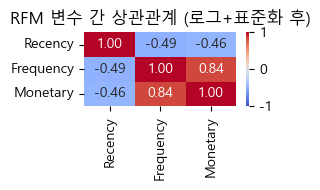

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(3,2))
sns.heatmap(
    rfm_scaled[feature_names].corr(),
    vmin=-1, vmax=1,          # 음의 상관 표시 필수
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0
)
plt.title('RFM 변수 간 상관관계 (로그+표준화 후)')
plt.tight_layout()
plt.show()

k=5 부근부터 완만한 감소 구간

k= 2 | inertia=   8460.7 | silhouette=0.4387
k= 3 | inertia=   6435.1 | silhouette=0.3450
k= 4 | inertia=   4830.6 | silhouette=0.3739
k= 5 | inertia=   4062.6 | silhouette=0.3424
k= 6 | inertia=   3563.2 | silhouette=0.3378
k= 7 | inertia=   3206.1 | silhouette=0.2926
k= 8 | inertia=   2921.3 | silhouette=0.2938
k= 9 | inertia=   2703.8 | silhouette=0.2962
k=10 | inertia=   2501.5 | silhouette=0.2840

Elbow 기준 k: 5
Silhouette 기준 k: 2
최종 선택 k: 5


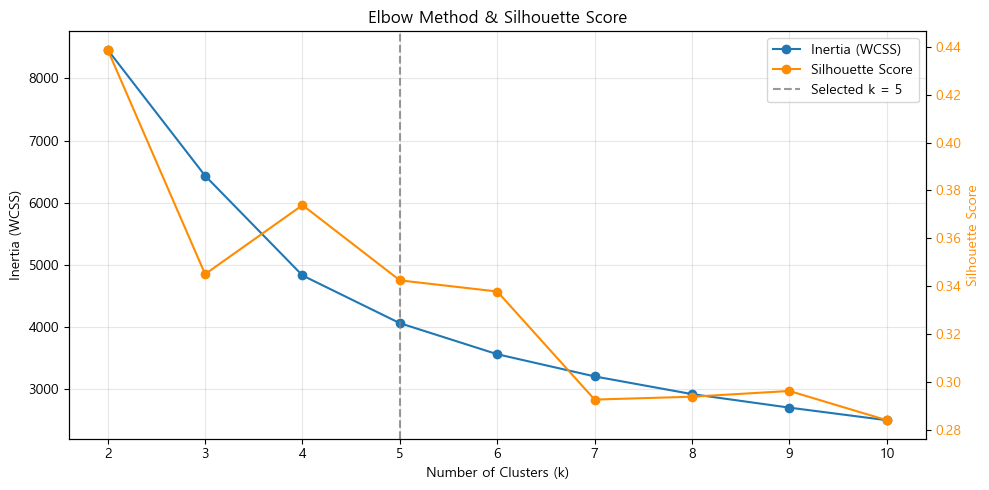

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

X = rfm_scaled[feature_names]
k_range = list(range(2, 11))

inertias = []
silhouettes = []

# =========================
# K별 평가
# =========================
for k in k_range:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X)

    inertias.append(km.inertia_)
    silhouettes.append(
        silhouette_score(X, labels)
    )

    print(
        f"k={k:2d} | "
        f"inertia={km.inertia_:9.1f} | "
        f"silhouette={silhouettes[-1]:.4f}"
    )

# =========================
# Elbow 기준
# =========================
knee = KneeLocator(
    k_range,
    inertias,
    curve='convex',
    direction='decreasing'
)

elbow_k = knee.elbow

# =========================
# Silhouette 기준
# =========================
silhouette_k = k_range[np.argmax(silhouettes)]

# =========================
# 최종 k 선택
# =========================
if elbow_k is not None:

    elbow_idx = k_range.index(elbow_k)

    max_sil = max(silhouettes)
    elbow_sil = silhouettes[elbow_idx]

    # Elbow 지점의 실루엣이 최대값의 70% 이상이면 채택
    if elbow_sil >= max_sil * 0.70:
        best_k = elbow_k
    else:
        best_k = silhouette_k

else:
    best_k = silhouette_k


print(f"\nElbow 기준 k: {elbow_k}")
print(f"Silhouette 기준 k: {silhouette_k}")
print(f"최종 선택 k: {best_k}")


# =========================
# 하나의 그래프에 표시
# =========================
fig, ax1 = plt.subplots(figsize=(10, 5))

# Elbow / Inertia
line1 = ax1.plot(
    k_range,
    inertias,
    'o-',
    label='Inertia (WCSS)'
)

ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_xticks(k_range)
ax1.grid(alpha=0.3)

# 오른쪽 y축 생성
ax2 = ax1.twinx()

# Silhouette - 주황색
line2 = ax2.plot(
    k_range,
    silhouettes,
    'o-',
    color='darkorange',
    label='Silhouette Score'
)

ax2.set_ylabel(
    'Silhouette Score',
    color='darkorange'
)

ax2.tick_params(
    axis='y',
    labelcolor='darkorange'
)

# 최종 선택 k 표시
ax1.axvline(
    best_k,
    linestyle='--',
    color='gray',
    alpha=0.8,
    label=f'Selected k = {best_k}'
)

# 범례 합치기
lines = line1 + line2
labels = [line.get_label() for line in lines]

selected_line = ax1.get_lines()[-1]
lines.append(selected_line)
labels.append(selected_line.get_label())

ax1.legend(
    lines,
    labels,
    loc='best'
)

plt.title('Elbow Method & Silhouette Score')
plt.tight_layout()
plt.show()

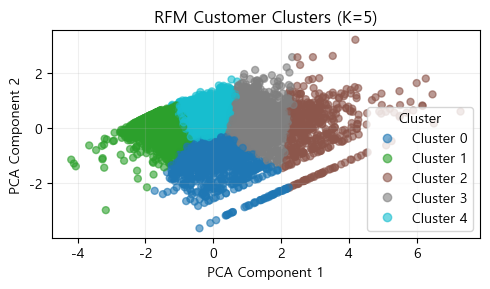

PCA 설명분산: [0.738 0.209]
누적 설명분산: 0.947


In [36]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# =========================
# 1. 최적 k로 KMeans 학습
# =========================
kmeans = KMeans(
    n_clusters=best_k,   # 앞에서 선택된 best_k = 5
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X)

# RFM 데이터에 군집 번호 저장
rfm_cluster['cluster_5'] = labels


# =========================
# 2. PCA로 RFM 3차원 → 2차원 축소
# =========================
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)


# =========================
# 3. 산점도
# =========================
plt.figure(figsize=(5, 3))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    cmap='tab10',
    alpha=0.6,
    s=25
)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'RFM Customer Clusters (K={best_k})')

plt.legend(
    scatter.legend_elements()[0],
    [f'Cluster {i}' for i in range(best_k)],
    title='Cluster'
)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# PCA가 원래 RFM 정보를 얼마나 설명하는지
print(
    'PCA 설명분산:',
    pca.explained_variance_ratio_.round(3)
)

print(
    '누적 설명분산:',
    pca.explained_variance_ratio_.sum().round(3)
)

# PC1은 Frequency와 Monetary가 높고 Recency가 낮을수록 증가하므로, 고객의 종합적인 구매가치·활성도를 나타내는 축으로 해석

In [37]:
import pandas as pd

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=['PC1', 'PC2']
)

print(loadings)

                PC1       PC2
Recency   -0.484551  0.874056
Frequency  0.621907  0.315945
Monetary   0.615177  0.369060


In [38]:
rfm_compare = rfm_cluster.copy()

for k in [4, 5]:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    rfm_compare[f'cluster_{k}'] = km.fit_predict(X)

    profile = (
        rfm_compare
        .groupby(f'cluster_{k}')
        .agg(
            고객수=('Customer ID', 'count'),
            R=('Recency', 'mean'),
            F=('Frequency', 'mean'),
            M=('Monetary', 'mean')
        )
        .round(1)
    )

    print(f"\n=== k={k} ===")
    print(profile.sort_values('M', ascending=False))


=== k=4 ===
            고객수      R     F        M
cluster_4                            
2          1023   32.7  19.2  10361.9
3          1486  213.9   5.1   1826.4
1          1056   23.1   2.8    860.4
0          2050  371.0   1.4    320.0

=== k=5 ===
            고객수      R     F        M
cluster_5                            
2           459   19.2  29.4  17650.2
3          1159   71.6   8.9   3513.4
4          1404  275.8   3.5   1138.1
0           937   22.9   2.5    743.4
1          1656  384.0   1.2    248.2


In [39]:
print(df_train.loc[df_train['Quantity'] > 20000, 
                   ['Invoice','StockCode','Quantity','InvoiceDate','Customer ID']])

       Invoice StockCode  Quantity         InvoiceDate Customer ID
550441  541431     23166     74215 2011-01-18 10:01:00       12346


,Recency,Frequency,Monetary
cluster_5,,,
0,-1.131,-0.423,-0.283
1,0.835,-0.902,-1.029
2,-1.469,2.103,1.753
3,-0.436,0.907,0.897
4,0.610,-0.090,0.089


cluster_5
0     937
1    1656
2     459
3    1159
4    1404
Name: count, dtype: int64


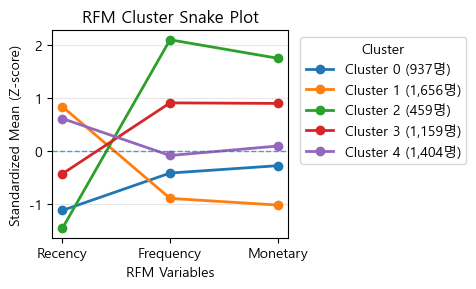

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. 표준화된 RFM 데이터에 Customer ID 추가
# ==========================================

snake_df = rfm_scaled[feature_names].copy()
snake_df['Customer ID'] = rfm_cluster['Customer ID'].values

# ==========================================
# 2. Customer ID 기준으로 cluster_5 병합
# ==========================================

snake_df = snake_df.merge(
    rfm_cluster[['Customer ID', 'cluster_5']],
    on='Customer ID',
    how='left',
    validate='one_to_one'
)

# 병합 이상 여부 확인
assert snake_df['cluster_5'].notna().all(), \
    "일부 Customer ID에 cluster가 매칭되지 않았습니다."

# ==========================================
# 3. 클러스터별 표준화 RFM 평균
# ==========================================

snake_mean = (
    snake_df
    .groupby('cluster_5')[feature_names]
    .mean()
)

display(snake_mean.round(3))


# ==========================================
# 4. 클러스터별 고객 수
# ==========================================

cluster_counts = (
    snake_df['cluster_5']
    .value_counts()
    .sort_index()
)

print(cluster_counts)


# ==========================================
# 5. Snake Plot
# ==========================================

plt.figure(figsize=(5, 3))

x = range(len(feature_names))

for cluster in snake_mean.index:

    values = snake_mean.loc[cluster, feature_names]
    n = cluster_counts.loc[cluster]

    plt.plot(
        x,
        values,
        marker='o',
        linewidth=2,
        label=f'Cluster {cluster} ({n:,}명)'
    )

# 표준화 평균 기준선
plt.axhline(
    0,
    linestyle='--',
    linewidth=1,
    alpha=0.7
)

plt.xticks(
    x,
    feature_names
)

plt.ylabel('Standardized Mean (Z-score)')
plt.xlabel('RFM Variables')
plt.title('RFM Cluster Snake Plot')

plt.legend(
    title='Cluster',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [41]:
cluster_name_map = {
    0: 'Lost',
    1: 'New / Promising',
    2: 'Loyal',
    3: 'Champions',
    4: 'At Risk'
}

rfm_cluster['Segment'] = rfm_cluster['cluster_5'].map(cluster_name_map)

In [42]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# ============================================================
# 0. 기본 설정
# ============================================================
N_CLUSTERS = 5
RANDOM_STATE = 42
EPSILON = 1e-8

required_cols = [
    'Invoice',
    'InvoiceDate',
    'Customer ID',
    'Quantity',
    'Price',
    'Sales'
]

missing_cols = [
    col for col in required_cols
    if col not in df_train.columns
]

if missing_cols:
    raise ValueError(
        f"df_train에 필요한 칼럼이 없습니다: {missing_cols}"
    )


# ============================================================
# 1. 거래 데이터 준비
# ============================================================
tx = df_train[required_cols].copy()

tx['Invoice'] = (
    tx['Invoice']
    .astype(str)
    .str.strip()
)

tx['InvoiceDate'] = pd.to_datetime(
    tx['InvoiceDate'],
    errors='coerce'
)

tx['Quantity'] = pd.to_numeric(
    tx['Quantity'],
    errors='coerce'
)

tx['Price'] = pd.to_numeric(
    tx['Price'],
    errors='coerce'
)

tx['Sales'] = pd.to_numeric(
    tx['Sales'],
    errors='coerce'
)

tx = tx.dropna(
    subset=[
        'InvoiceDate',
        'Customer ID',
        'Quantity',
        'Price',
        'Sales'
    ]
).copy()

# 고객 ID 표현 통일
tx['Customer ID'] = (
    tx['Customer ID']
    .astype(str)
)

# 월 단위
tx['YearMonth'] = (
    tx['InvoiceDate']
    .dt.to_period('M')
)

# 정상 구매 여부
tx['is_purchase'] = (
    ~tx['Invoice'].str.startswith('C')
    & (tx['Quantity'] > 0)
)

print("거래 데이터 준비 완료")
print("거래 행 수:", len(tx))
print("고객 수:", tx['Customer ID'].nunique())
print(
    "기간:",
    tx['InvoiceDate'].min(),
    "~",
    tx['InvoiceDate'].max()
)


# ============================================================
# 2. 고객 × 월 순매출 및 순수량 집계
# ============================================================
monthly_net = (
    tx
    .groupby(
        ['Customer ID', 'YearMonth'],
        as_index=False
    )
    .agg(
        monthly_sales=('Sales', 'sum'),
        monthly_quantity=('Quantity', 'sum')
    )
)

# 화폐 및 수량 계산 오차 정리
monthly_net['monthly_sales'] = (
    monthly_net['monthly_sales']
    .round(2)
)

monthly_net['monthly_quantity'] = (
    monthly_net['monthly_quantity']
    .round(6)
)

monthly_net['monthly_sales'] = (
    monthly_net['monthly_sales']
    .mask(
        monthly_net['monthly_sales'].abs() < EPSILON,
        0
    )
)

monthly_net['monthly_quantity'] = (
    monthly_net['monthly_quantity']
    .mask(
        monthly_net['monthly_quantity'].abs() < EPSILON,
        0
    )
)


# ============================================================
# 3. 정상 구매 기준 월별 주문 횟수와 마지막 구매일
# ============================================================
purchase_tx = tx[
    tx['is_purchase']
].copy()

if purchase_tx.empty:
    raise ValueError(
        "정상 구매 거래가 없습니다."
    )

monthly_purchase = (
    purchase_tx
    .groupby(
        ['Customer ID', 'YearMonth'],
        as_index=False
    )
    .agg(
        monthly_orders=('Invoice', 'nunique'),
        monthly_last_purchase=('InvoiceDate', 'max')
    )
)

monthly = monthly_net.merge(
    monthly_purchase,
    on=['Customer ID', 'YearMonth'],
    how='left',
    validate='one_to_one'
)

monthly['monthly_orders'] = (
    monthly['monthly_orders']
    .fillna(0)
    .astype(int)
)


# ============================================================
# 4. 고객별 최초 구매월부터 마지막 관측월까지 패널 생성
# ============================================================
first_purchase_month = (
    purchase_tx
    .groupby('Customer ID')['YearMonth']
    .min()
)

last_observed_month = (
    tx['YearMonth']
    .max()
)

panel_parts = []

for customer_id, start_month in first_purchase_month.items():

    customer_months = pd.period_range(
        start=start_month,
        end=last_observed_month,
        freq='M'
    )

    customer_panel = pd.DataFrame({
        'Customer ID': customer_id,
        'YearMonth': customer_months
    })

    panel_parts.append(customer_panel)

panel = pd.concat(
    panel_parts,
    ignore_index=True
)

panel = panel.merge(
    monthly,
    on=['Customer ID', 'YearMonth'],
    how='left',
    validate='one_to_one'
)

fill_zero_cols = [
    'monthly_sales',
    'monthly_quantity',
    'monthly_orders'
]

panel[fill_zero_cols] = (
    panel[fill_zero_cols]
    .fillna(0)
)

panel['monthly_sales'] = (
    panel['monthly_sales']
    .round(2)
)

panel['monthly_quantity'] = (
    panel['monthly_quantity']
    .round(6)
)

panel['monthly_orders'] = (
    panel['monthly_orders']
    .astype(int)
)

panel = (
    panel
    .sort_values(
        ['Customer ID', 'YearMonth']
    )
    .reset_index(drop=True)
)


# ============================================================
# 5. Recency 계산
# ============================================================
panel['last_purchase_date'] = (
    panel
    .groupby('Customer ID')[
        'monthly_last_purchase'
    ]
    .ffill()
)

# 날짜와 시간을 날짜 단위로 통일
panel['last_purchase_date'] = (
    pd.to_datetime(
        panel['last_purchase_date'],
        errors='coerce'
    )
    .dt.normalize()
)

panel['month_end'] = (
    panel['YearMonth']
    .dt.to_timestamp(how='end')
    .dt.normalize()
)

panel['Recency'] = (
    panel['month_end']
    - panel['last_purchase_date']
).dt.days

negative_recency_count = (
    panel['Recency']
    .dropna()
    .lt(0)
    .sum()
)

if negative_recency_count > 0:
    raise ValueError(
        f"음수 Recency가 {negative_recency_count}건 있습니다."
    )


# ============================================================
# 6. 누적 Frequency 및 Monetary 계산
# ============================================================
panel['Frequency'] = (
    panel
    .groupby('Customer ID')[
        'monthly_orders'
    ]
    .cumsum()
)

panel['Monetary'] = (
    panel
    .groupby('Customer ID')[
        'monthly_sales'
    ]
    .cumsum()
    .round(2)
)

# 사실상 0인 부동소수점 오차 제거
panel['Monetary'] = (
    panel['Monetary']
    .mask(
        panel['Monetary'].abs() < EPSILON,
        0
    )
)

print("\nMonetary 최소값:")
print(panel['Monetary'].min())

print(
    "사실상 0인 Monetary 수:",
    (panel['Monetary'].abs() < EPSILON).sum()
)


# ============================================================
# 7. 월별 행동 변수 생성
# ============================================================
customer_group = panel.groupby(
    'Customer ID',
    group_keys=False
)

# YearMonth가 2010-06일 경우:
# lag_1 = 2010-06
# lag_2 = 2010-05
# lag_3 = 2010-04

panel['sales_lag_1'] = (
    panel['monthly_sales']
)

panel['sales_lag_2'] = (
    customer_group['monthly_sales']
    .shift(1)
)

panel['sales_lag_3'] = (
    customer_group['monthly_sales']
    .shift(2)
)

panel['orders_lag_1'] = (
    panel['monthly_orders']
)

panel['orders_lag_2'] = (
    customer_group['monthly_orders']
    .shift(1)
)

panel['orders_lag_3'] = (
    customer_group['monthly_orders']
    .shift(2)
)

panel['quantity_lag_1'] = (
    panel['monthly_quantity']
)


# ============================================================
# 8. 고객 활동 기간과 계절 변수
# ============================================================
panel['first_purchase_month'] = (
    panel
    .groupby('Customer ID')[
        'YearMonth'
    ]
    .transform('min')
)

panel['customer_tenure'] = (
    (
        panel['YearMonth'].dt.year
        - panel['first_purchase_month'].dt.year
    ) * 12
    +
    (
        panel['YearMonth'].dt.month
        - panel['first_purchase_month'].dt.month
    )
)

panel['month'] = (
    panel['YearMonth']
    .dt.month
)


# ============================================================
# 9. 다음 달 타깃 생성
# ============================================================
customer_group = panel.groupby(
    'Customer ID',
    group_keys=False
)

panel['target_next_sales'] = (
    customer_group['monthly_sales']
    .shift(-1)
)

panel['next_month_orders'] = (
    customer_group['monthly_orders']
    .shift(-1)
)

panel['target_next_purchase'] = np.where(
    panel['next_month_orders'].isna(),
    np.nan,
    (
        panel['next_month_orders'] > 0
    ).astype(int)
)

# 다음 달 정답이 없는 마지막 관측월 제거
panel_model = panel[
    panel['target_next_sales'].notna()
].copy()

panel_model['target_next_sales'] = (
    panel_model['target_next_sales']
    .round(2)
)

panel_model['target_next_purchase'] = (
    panel_model['target_next_purchase']
    .astype(int)
)


# ============================================================
# 10. RFM 군집화 대상 생성
# ============================================================
segment_features = [
    'Recency',
    'Frequency',
    'Monetary'
]

segment_mask = (
    panel_model[segment_features]
    .notna()
    .all(axis=1)
    & (panel_model['Recency'] >= 0)
    & (panel_model['Frequency'] > 0)
    & (panel_model['Monetary'] > EPSILON)
)

segment_data = (
    panel_model
    .loc[
        segment_mask,
        segment_features
    ]
    .astype(float)
    .copy()
)

if len(segment_data) < N_CLUSTERS:
    raise ValueError(
        "군집화할 고객-월 데이터가 너무 적습니다."
    )

print("\nRFM 군집화 대상")
print("대상 행 수:", len(segment_data))
print(segment_data.describe().round(2))


# ============================================================
# 11. 로그 변환 및 유한값 검증
# ============================================================
segment_log = np.log1p(
    segment_data
)

segment_array = (
    segment_log
    .to_numpy(dtype=float)
)

is_finite = np.isfinite(
    segment_array
).all(axis=1)

if not is_finite.all():

    bad_rows = (
        segment_log
        .loc[~is_finite]
    )

    print("\n로그 변환 이상 행")
    print(bad_rows.head(20))

    raise ValueError(
        "RFM 로그 데이터에 NaN 또는 무한값이 있습니다."
    )

print("\n로그 변환 후 왜도")
print(segment_log.skew())


# ============================================================
# 12. 표준화 및 K-means 군집화
# ============================================================
segment_scaler = StandardScaler()

segment_scaled = (
    segment_scaler
    .fit_transform(segment_log)
)

segment_kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=10
)

segment_labels = (
    segment_kmeans
    .fit_predict(segment_scaled)
)

panel_model['cluster_5'] = pd.Series(
    pd.NA,
    index=panel_model.index,
    dtype='Int64'
)

panel_model.loc[
    segment_mask,
    'cluster_5'
] = segment_labels


# ============================================================
# 13. 군집 프로필 출력
# ============================================================
segment_profile = (
    panel_model
    .dropna(subset=['cluster_5'])
    .groupby('cluster_5')
    .agg(
        고객월수=('Customer ID', 'size'),
        고유고객수=('Customer ID', 'nunique'),
        R=('Recency', 'mean'),
        F=('Frequency', 'mean'),
        M=('Monetary', 'mean')
    )
    .round(1)
    .sort_values(
        'M',
        ascending=False
    )
)

print("\n=== 월별 RFM 군집 프로필 ===")
print(segment_profile)

거래 데이터 준비 완료
거래 행 수: 711094
고객 수: 5651
기간: 2009-12-01 07:45:00 ~ 2011-10-30 16:17:00

Monetary 최소값:
-1663.06
사실상 0인 Monetary 수: 208

RFM 군집화 대상
대상 행 수: 80408
        Recency  Frequency   Monetary
count  80408.00   80408.00   80408.00
mean     126.36       4.42    1960.74
std      129.75       8.50    9061.69
min        0.00       1.00       1.15
25%       27.00       1.00     285.81
50%       79.00       2.00     632.40
75%      188.00       5.00    1573.13
max      668.00     306.00  498910.75

로그 변환 후 왜도
Recency     -0.707428
Frequency    1.274313
Monetary     0.289514
dtype: float64

=== 월별 RFM 군집 프로필 ===
            고객월수  고유고객수      R     F        M
cluster_5                                    
0           5567    868   17.8  23.5  14269.9
3          15082   2181   53.3   7.1   2805.9
1          20062   2869  168.2   3.0   1063.6
2          14224   5288   19.4   2.0    590.2
4          25473   3204  220.1   1.2    242.0


In [52]:
# ============================================================
# 14. 군집 번호에 세그먼트 이름 부여
# ============================================================
panel_cluster_name_map = {
    0: 'Champions',
    3: 'Loyal',
    2: 'New / Promising',
    1: 'At Risk',
    4: 'Lost'
}

panel_model['Segment'] = panel_model['cluster_5'].map(panel_cluster_name_map)

# 라벨 자동검증 (다음에 라벨 또 바뀌면 여기서 에러남)
prof = (panel_model.dropna(subset=['cluster_5'])
        .groupby('cluster_5')[['Recency','Frequency','Monetary']].mean())
assert panel_cluster_name_map[prof['Monetary'].idxmax()] == 'Champions'
assert panel_cluster_name_map[prof['Recency'].idxmax()] == 'Lost'

print("\n=== 세그먼트 분포 ===")
print(panel_model['Segment'].value_counts(dropna=False))


=== 세그먼트 분포 ===
Segment
Lost               25473
At Risk            20062
Loyal              15082
New / Promising    14224
Champions           5567
NaN                  259
Name: count, dtype: int64


In [45]:
nan_rows = panel_model[
    panel_model['Segment'].isna()
].copy()

print("NaN 행 수:", len(nan_rows))

print(
    nan_rows[
        ['Recency', 'Frequency', 'Monetary']
    ].describe()
)

print("\n제외 원인")
print({
    'Recency 결측': nan_rows['Recency'].isna().sum(),
    'Recency 음수': (nan_rows['Recency'] < 0).sum(),
    'Frequency 0 이하': (nan_rows['Frequency'] <= 0).sum(),
    'Monetary 0 이하': (nan_rows['Monetary'] <= EPSILON).sum()
})

NaN 행 수: 259
          Recency   Frequency     Monetary
count  259.000000  259.000000   259.000000
mean   195.169884    1.281853  -181.635560
std    149.776067    0.763572   468.862026
min      0.000000    1.000000 -1663.060000
25%     75.000000    1.000000     0.000000
50%    165.000000    1.000000     0.000000
75%    286.500000    1.000000     0.000000
max    668.000000    4.000000     0.000000

제외 원인
{'Recency 결측': np.int64(0), 'Recency 음수': np.int64(0), 'Frequency 0 이하': np.int64(0), 'Monetary 0 이하': np.int64(259)}


In [46]:
# ============================================================
# 15. 최종 CSV 생성
# ============================================================
export_cols = [
    'Customer ID',
    'YearMonth',
    'Recency',
    'Frequency',
    'Monetary',
    'Segment',
    'sales_lag_1',
    'sales_lag_2',
    'sales_lag_3',
    'orders_lag_1',
    'orders_lag_2',
    'orders_lag_3',
    'quantity_lag_1',
    'customer_tenure',
    'month',
    'target_next_sales',
    'target_next_purchase'
]

customer_month_panel = (
    panel_model[export_cols]
    .sort_values(
        ['Customer ID', 'YearMonth']
    )
    .reset_index(drop=True)
    .copy()
)

lag_cols = [
    'sales_lag_1',
    'sales_lag_2',
    'sales_lag_3',
    'orders_lag_1',
    'orders_lag_2',
    'orders_lag_3',
    'quantity_lag_1'
]

customer_month_panel[lag_cols] = (
    customer_month_panel[lag_cols]
    .fillna(0)
)

# 금액 변수 반올림
money_cols = [
    'Monetary',
    'sales_lag_1',
    'sales_lag_2',
    'sales_lag_3',
    'target_next_sales'
]

customer_month_panel[money_cols] = (
    customer_month_panel[money_cols]
    .round(2)
)

# 수량 반올림
customer_month_panel['quantity_lag_1'] = (
    customer_month_panel['quantity_lag_1']
    .round(6)
)

# 군집화되지 않은 Monetary <= 0 고객-월 제외
customer_month_panel = (
    customer_month_panel
    .dropna(subset=['Segment'])
    .reset_index(drop=True)
)

# CSV 호환을 위해 문자열 변환
customer_month_panel['YearMonth'] = (
    customer_month_panel['YearMonth']
    .astype(str)
)

output_path = 'customer_month_rfm_panel.csv'

customer_month_panel.to_csv(
    output_path,
    index=False,
    encoding='utf-8-sig'
)

print("\n저장 완료:", output_path)
print("최종 행 수:", len(customer_month_panel))
print(
    "고객 수:",
    customer_month_panel[
        'Customer ID'
    ].nunique()
)
print(
    "기간:",
    customer_month_panel[
        'YearMonth'
    ].min(),
    "~",
    customer_month_panel[
        'YearMonth'
    ].max()
)

print("\n세그먼트 분포")
print(
    customer_month_panel[
        'Segment'
    ].value_counts()
)

print("\n다음 달 구매 여부 분포")
print(
    customer_month_panel[
        'target_next_purchase'
    ].value_counts()
)

print("\n최종 데이터 미리보기")
print(customer_month_panel.head(10))


저장 완료: customer_month_rfm_panel.csv
최종 행 수: 80408
고객 수: 5406
기간: 2009-12 ~ 2011-09

세그먼트 분포
Segment
At Risk            25473
Lost               20062
Champions          15082
New / Promising    14224
Loyal               5567
Name: count, dtype: int64

다음 달 구매 여부 분포
target_next_purchase
0    62870
1    17538
Name: count, dtype: int64

최종 데이터 미리보기
  Customer ID YearMonth  Recency  Frequency  Monetary          Segment  \
0       12346   2010-03       29          1     27.05          At Risk   
1       12346   2010-04       59          1     27.05          At Risk   
2       12346   2010-05       90          1     27.05          At Risk   
3       12346   2010-06        2          2    169.36  New / Promising   
4       12346   2010-07       33          2    169.36  New / Promising   
5       12346   2010-08       64          2    169.36          At Risk   
6       12346   2010-09       94          2    169.36          At Risk   
7       12346   2010-10      125          2    169.36      

In [47]:
print("\n결측값 개수")
print(customer_month_panel.isna().sum())

print("\n중복 고객-월 수")
print(
    customer_month_panel.duplicated(
        subset=['Customer ID', 'YearMonth']
    ).sum()
)

print("\n무한값 수")
numeric_cols = customer_month_panel.select_dtypes(
    include='number'
).columns

print(
    np.isinf(
        customer_month_panel[numeric_cols]
        .to_numpy(dtype=float)
    ).sum()
)


결측값 개수
Customer ID             0
YearMonth               0
Recency                 0
Frequency               0
Monetary                0
Segment                 0
sales_lag_1             0
sales_lag_2             0
sales_lag_3             0
orders_lag_1            0
orders_lag_2            0
orders_lag_3            0
quantity_lag_1          0
customer_tenure         0
month                   0
target_next_sales       0
target_next_purchase    0
dtype: int64

중복 고객-월 수
0

무한값 수
0


In [ ]:
tmp = tx.copy()
tmp['first_pm'] = tmp['Customer ID'].map(first_purchase_month)

no_purchase = tmp['first_pm'].isna()                    # 구매 없이 취소만 있는 고객
before_first = ~no_purchase & (tmp['YearMonth'] < tmp['first_pm'])

print('구매이력 없는 고객:', round(tmp.loc[no_purchase,'Sales'].sum(),2),
      '| 고객수', tmp.loc[no_purchase,'Customer ID'].nunique())
print('첫구매 이전 취소:', round(tmp.loc[before_first,'Sales'].sum(),2))
print('합계:', round(tmp.loc[no_purchase|before_first,'Sales'].sum(),2))
# 구매 이력이 없는 취소 전용 고객 23명과 첫 구매월 이전 반품 건은 패널에서 제외했으며, 이는 전체 순매출의 0.03% 수준이다.

구매이력 없는 고객: -1406.13 | 고객수 23
첫구매 이전 취소: -3325.17
합계: -4731.3
